# Trabajo Práctico - Aprendizaje Automático

## SetUp




In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install pingouin
import pingouin as pg
from scipy.stats import shapiro

from six import StringIO  #pip3 install six
import math

from IPython.display import Image, display
import pydotplus

import sklearn
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_validate, StratifiedKFold, ParameterGrid, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import recall_score


In [4]:
# Seteamos la semilla para que los resultados sean reproducibles
SEED = 2026
np.random.seed(SEED)

# Definimos el K-Fold estratificado para usar en la validación cruzada de los modelos
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Definición de Funciones

In [5]:
# Función para separar el dataset en train y test, manteniendo la proporción de clases
def train_test_split(df):
    buen_pronostico = df[df['target'] == 1]
    p = buen_pronostico.shape[0]/df.shape[0]

    mal_pronostico = df[df['target'] == 0]
    buenos = len(buen_pronostico)/len(df)
    filasBuenas = int(len(df)*buenos*p)
    filasMalas = int(len(df)*p-filasBuenas)
    # buscar como selecciona .sample()
    test = pd.DataFrame(columns=buen_pronostico.columns).astype(buen_pronostico.dtypes)
    test = pd.concat([test, buen_pronostico.sample(n=filasBuenas, random_state=SEED)], ignore_index=False)
    test = pd.concat([test, mal_pronostico.sample(n=filasMalas, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)
    return train.drop(columns=['target']), train['target'], test.drop(columns=['target']), test['target']

## Separación de Datos de Desarrollo y Control

In [7]:
df_completo = pd.read_csv('data.csv')

In [8]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
X_train, y_train, X_control, y_control = train_test_split(df_completo)

df_control = pd.concat([X_control, y_control], axis=1)
df = pd.concat([X_train, y_train], axis=1)

Decidimos dividir los datos en Desarrollo y Control. Si bien más adelante contaremos con un conjunto de datos de control, esta primera instancia de validación nos permite ajustar el modelo y asegurar su capacidad de generalización antes datos totalmente nuevos. Una vez validada esta etapa, integraremos nuestros datos de control interno al conjunto de entrenamiento general.     

Para asegurar una representación fiel de los datos, utilizamos siempre particiones estratificadas (stratify), lo que nos permite controlar el desbalance de clases.

## Ejercicio 2

In [9]:
# Función para entrenar un árbol de decisión con una semilla fija
def train_tree(X_tr: np.ndarray, y_tr: np.ndarray, tree_params={}) -> DecisionTreeClassifier:
    arbol = DecisionTreeClassifier(**tree_params, random_state=SEED)
    arbol.fit(X_tr, y_tr)

    return arbol

def dibujar_arbol(clf, c_name=['0','1'], f_name=df.drop(columns=['target']).columns):
    # modo de uso: dibujar_arbol(arbol, nombres_de_clases, nombres_de_features)
    if(c_name is None or f_name is None):
        return "Debe especificar los nombres de las clases y de las features"

    dot_data = StringIO()
    sklearn.tree.export_graphviz(clf, out_file = dot_data,
                    filled = True,
                    class_names = c_name,
                    feature_names = f_name,
                    special_characters = True)

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    display(Image(graph.create_png()))

In [10]:
def stratifiedKFoldCV(algoritmo, X_train, y_train, cv):
    resultados_folds = []

    y_global_true = np.empty(len(y_train))
    y_global_pred = np.empty(len(y_train))
    y_global_proba = np.empty(len(y_train)) # El nombre proba es por aucroc devuelve la probabilidad de pertenecer a la clase.

    for fold_idx, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):

        kf_X_train, kf_X_test = X_train.iloc[train_index], X_train.iloc[val_index]
        kf_y_train, kf_y_test = y_train.iloc[train_index], y_train.iloc[val_index]

        algoritmo.fit(kf_X_train, kf_y_train)

        y_pred_train = algoritmo.predict(kf_X_train)
        y_pred_test = algoritmo.predict(kf_X_test)
        #y_pred_control = modelo.predict(X_control)
        #y_pred_proba_control = algoritmo.predict_proba(X_control)[:,1]
        #acc_control = accuracy_score(y_control,y_pred_control)
        #auc_prc_control = average_precision_score(y_control, y_pred_proba_control)
        #auc_roc_control = roc_auc_score(y_control, y_pred_proba_control)

        y_pred_proba_train = algoritmo.predict_proba(kf_X_train)[:, 1] # Probabilidad de pertenecer a la clase positiva
        y_pred_proba_test = algoritmo.predict_proba(kf_X_test)[:, 1]

        y_global_true[val_index] = kf_y_test
        y_global_pred[val_index] = y_pred_test
        y_global_proba[val_index] = y_pred_proba_test

        resultados_folds.append({
            'Permutación': str(fold_idx),
            'Accuracy (train)': accuracy_score(kf_y_train, y_pred_train),
            'Accuracy (validation)': accuracy_score(kf_y_test, y_pred_test),
            'AUC-PRC (train)': average_precision_score(kf_y_train, y_pred_proba_train),
            'AUC-PRC (validation)': average_precision_score(kf_y_test, y_pred_proba_test),
            'AUC-ROC (train)': roc_auc_score(kf_y_train, y_pred_proba_train),
            'AUC-ROC (validation)': roc_auc_score(kf_y_test, y_pred_proba_test)
        })

    df_tabla = pd.DataFrame(resultados_folds)

    promedios = df_tabla.drop(columns=['Permutación']).mean()
    df_tabla.loc[len(df_tabla)] = ['Promedios'] + list(promedios)

    df_tabla.loc[len(df_tabla)] = [
        'Global',
        '(NO)',
        accuracy_score(y_global_true, y_global_pred),
        '(NO)',
        average_precision_score(y_global_true, y_global_proba),
        '(NO)',
        roc_auc_score(y_global_true, y_global_proba)
    ]

    return df_tabla

### Ejercicio 2.1

In [11]:
X_train, y_train, X_test, y_test = train_test_split(df)

tree_1 = train_tree(X_train, y_train, tree_params={'max_depth': 3})

print("Score sobre el dataset de entrenamiento: ", tree_1.score(X_train, y_train))
print("Score sobre el dataset de prueba: ", tree_1.score(X_test, y_test))


Score sobre el dataset de entrenamiento:  0.8326848249027238
Score sobre el dataset de prueba:  0.6764705882352942


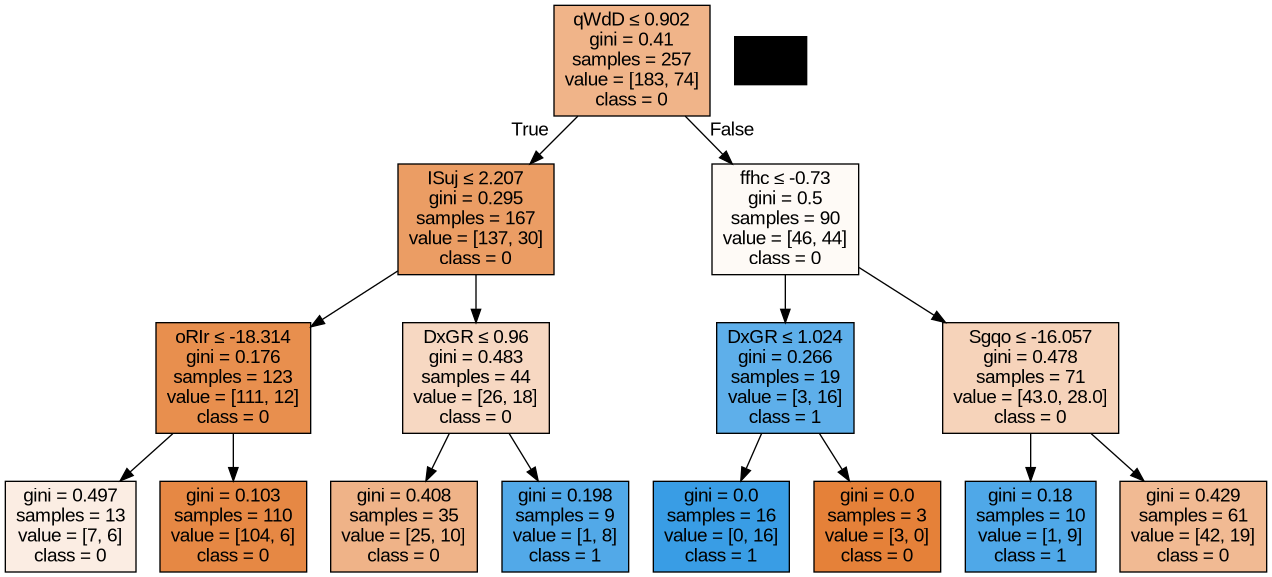

In [12]:
dibujar_arbol(tree_1)

### Ejercicio 2.2

In [13]:
tree = DecisionTreeClassifier(max_depth=3, random_state=SEED)
X_train, y_train = df.drop(columns=['target']), df['target']

stratifiedKFoldCV(tree, X_train, y_train, stratifiedKFold)

,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,0.815331,0.652778,0.695888,0.277060,0.813444,0.494712
1,1,0.8223,0.736111,0.651793,0.425710,0.843575,0.672115
2,2,0.843206,0.666667,0.687339,0.379398,0.876214,0.627451
3,3,0.843206,0.638889,0.705033,0.359391,0.846578,0.573296
4,4,0.822917,0.633803,0.684681,0.375528,0.844305,0.639216
5,Promedios,0.829392,0.665649,0.684947,0.363417,0.844823,0.601358
6,Global,(NO),0.665738,(NO),0.357207,(NO),0.612173


### Ejercicio 2.3

In [14]:
def grid_search_tree(X_train, y_train, param_grid={'max_depth': [3,5,None], 'criterion': ['gini', 'entropy']}, metric='accuracy'):
    grid = ParameterGrid(param_grid)
    res = []

    for params in grid:
        current_tree = DecisionTreeClassifier(**params, random_state=SEED)

        cv_results = cross_validate(
            current_tree,
            X_train,
            y_train,
            cv=stratifiedKFold,
            scoring=metric,
            return_train_score=True
        )

        fila = {}
        for param_name, param_value in params.items():
            if param_name == 'max_depth' and param_value is None:
                fila[param_name] = 'Infinito'
            else:
                fila[param_name] = param_value

        fila[f'{metric} (training)'] = cv_results['train_score'].mean()
        fila[f'{metric} (validación)'] = cv_results['test_score'].mean()

        res.append(fila)

    return pd.DataFrame(res)

In [15]:
X_train, y_train = df.drop(columns=['target']), df['target']
res = grid_search_tree(X_train, y_train)

res

,criterion,max_depth,accuracy (training),accuracy (validación)
0,gini,3,0.829392,0.665649
1,gini,5,0.943590,0.646166
2,gini,Infinito,1.000000,0.640532
3,entropy,3,0.804317,0.660250
4,entropy,5,0.923413,0.690884
5,entropy,Infinito,1.000000,0.660329


## Ejercicio 3

In [16]:
# Función para generar una tabla de resultados a partir de un objeto RandomizedSearchCV entrenado
def generar_tabla_resultados(busqueda_entrenada):
    df_resultados = pd.DataFrame(busqueda_entrenada.cv_results_)

    columnas_params = [col for col in df_resultados.columns if col.startswith('param_')]
    columnas_metricas = [
        'rank_test_score',
        'mean_test_score',
        'std_test_score'
    ]

    columnas_totales = columnas_metricas + columnas_params
    tabla_limpia = df_resultados[columnas_totales].sort_values(by='rank_test_score')

    mapeo_nombres = {col: col.replace('param_', '') for col in columnas_params}
    tabla_limpia = tabla_limpia.rename(columns=mapeo_nombres)

    return tabla_limpia

### Ejercicio 3.1

#### Árboles de Decisión

In [17]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions={
        'max_depth': [3, 5, 6, 7, None],
        'criterion': ['gini', 'entropy'],
        'max_features' : [None, 'sqrt', 'log2'],
        'min_samples_split' : [2, 3, 4, 5],
    }, # restringe el espacio de búsqueda a estos valores
    n_iter=10, # combinaciones aleatorias a probar
    scoring='roc_auc', # métrica a optimizar
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    n_jobs=-1 # esto permite usar todos los cores de CPU
)

random_search_tree.fit(X_train, y_train)

generar_tabla_resultados(random_search_tree)

,rank_test_score,mean_test_score,std_test_score,min_samples_split,max_features,max_depth,criterion
8,1,0.642855,0.026969,4,log2,3,gini
3,2,0.631872,0.088570,3,None,3,entropy
5,3,0.615945,0.067344,2,log2,None,entropy
9,4,0.615384,0.070609,4,None,5,entropy
1,5,0.588892,0.061876,4,sqrt,7,gini
6,6,0.580718,0.100473,4,sqrt,6,entropy
4,7,0.573726,0.069845,4,log2,7,gini
2,8,0.565449,0.084953,2,sqrt,5,gini
7,9,0.564359,0.067399,3,sqrt,7,gini
0,10,0.548128,0.049041,3,sqrt,None,gini


#### KNN

In [18]:
rsk = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions={
        'n_neighbors': range(1,20),
        'weights': ["uniform","distance"],
        'metric':["cityblock","cosine","euclidean"]
    },
    n_iter=10,
    scoring='roc_auc',
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,

)

rsk.fit(X_train, y_train)

generar_tabla_resultados(rsk)

,rank_test_score,mean_test_score,std_test_score,weights,n_neighbors,metric
9,1,0.832651,0.024303,distance,4,cosine
6,2,0.814244,0.019154,uniform,5,cosine
7,3,0.803655,0.037518,uniform,10,cityblock
5,4,0.802813,0.013292,uniform,19,cosine
2,5,0.792802,0.022356,uniform,12,euclidean
1,6,0.791084,0.024979,uniform,6,cityblock
8,7,0.774666,0.023855,uniform,7,euclidean
0,8,0.727904,0.045285,distance,3,euclidean
4,9,0.713931,0.041534,uniform,3,euclidean
3,10,0.702231,0.055826,distance,1,cosine


#### SVM

In [19]:
# para SVM solo tendría que hacer un plot y ver que me parece, ojala pudiese hacerlo  jajaja.
#
from sklearn.model_selection import RandomizedSearchCV



# Espacio de búsqueda de hiperparámetros
# Probar parámtero Gamma luego
# Kernel Exponencial Cuadrático = rbf (similar al qué está en el libro)
# Kernel sigmoid: ¿En qué casos es más útil?
# Revisar valores de C, la escala logaritmica es para explorar un rango grande de valores
# ya que no es lineal la relación entre los valores de C y el desempeño del modelo
param_dist = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': np.logspace(-3, 3, 7) # Valores de C en escala logarítmica
}

random_search_SVM = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=stratifiedKFold,
    random_state=SEED,
    n_jobs=-1
)

random_search_SVM.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=2026, shuffle=True),
                   estimator=SVC(), n_iter=20, n_jobs=-1,
                   param_distributions={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   random_state=2026, scoring='roc_auc')

In [ ]:
generar_tabla_resultados(random_search_SVM)


,rank_test_score,mean_test_score,std_test_score,kernel,C
0,1,0.861414,0.051967,rbf,10.000
1,1,0.861414,0.051967,rbf,100.000
8,1,0.861414,0.051967,rbf,1000.000
12,4,0.815603,0.052040,rbf,1.000
7,5,0.805426,0.056046,rbf,0.100
18,6,0.793437,0.051711,rbf,0.001
16,7,0.744905,0.075753,linear,0.001
2,8,0.733174,0.054845,poly,100.000
9,9,0.730150,0.036180,poly,10.000
5,10,0.720939,0.087202,sigmoid,0.001


### Ejercicio 3.2

#### LDA

In [21]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = LinearDiscriminantAnalysis()

resultados_nb = cross_validate(
    nb_model,
    X_train,
    y_train,
    cv=stratifiedKFold,
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_nb['test_score'].mean()
print(f"AUCROC promedio de LDA: {aucroc_promedio_nb:.4f}")

AUCROC promedio de LDA: 0.6392


#### Naive Bayes

In [22]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = GaussianNB()

resultados_nb = cross_validate(
    nb_model,
    X_train,
    y_train,
    cv=stratifiedKFold,
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_nb['test_score'].mean()
print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

AUCROC promedio de Naïve Bayes (Default): 0.7372


### Mejor Modelo

In [29]:
X_train, y_train = df.drop(columns=['target']), df['target']

# El mejor tiene hiperparametros:min_samples_split = 4, max_features = 'log2', criterion = 'gini', max_depth = 3
# Con un score en kfold de 0.642855
mejor_arbol = DecisionTreeClassifier(max_depth=4, criterion= 'gini', min_samples_split=4, max_features='log2', random_state=SEED)

# El mejor knn tiene hiperparametros: weights= 'distance', n_neighbors = 4, metric = 'cosine'
# Con un score en kfold de 0.832651
mejor_knn = KNeighborsClassifier(n_neighbors=4, weights='distance', metric='cosine')

# El mejor SVM tiene hiperparametros: kernel = 'rbf', C=10
# Con un score en kfold de 0.861414
mejor_svm = SVC(kernel= 'rbf', C= 10, probability=True)

#Agregamos tambien a la comparacion los modelos estandar de LDA y Naive Bayes
nb = GaussianNB()
lda = LinearDiscriminantAnalysis()

modelos = {
    "Mejor Arbol": mejor_arbol,
    "Mejor KNN": mejor_knn,
    "Mejor SVM": mejor_svm,
    "LDA": lda,
    "Naive Bayes": nb
}


resultados = []

for nombre_string, modelo in modelos.items():

  #y_pred_control = modelo.predict(X_control)
  #y_pred_proba_control = algoritmo.predict_proba(X_control)[:,1]
  #acc_control = accuracy_score(y_control,y_pred_control)
  #auc_prc_control = average_precision_score(y_control, y_pred_proba_control)
  #auc_roc_control = roc_auc_score(y_control, y_pred_proba_control)
  modelo.fit(X_train, y_train)
  y_pred_control = modelo.predict(X_control)
  y_pred_proba_control = modelo.predict_proba(X_control)[:,1]

  acc_por_clase = recall_score(y_control, y_pred_control, average=None)

  acc_mayoritaria = round(acc_por_clase[0] * 100,2)
  acc_minoritaria = round(acc_por_clase[1] * 100,2)
  #acc_control = accuracy_score(y_control,y_pred_control)
  #auc_prc_control = average_precision_score(y_control, y_pred_proba_control)
  #auc_roc_control = roc_auc_score(y_control, y_pred_proba_control)
  resultados.append({
            'Modelo': str(nombre_string),
            'Accuracy (control)': accuracy_score(y_control,y_pred_control),
            'Accuracy Mayoritaria (control)': acc_mayoritaria,
            'Accuracy Minoritaria (control)': acc_minoritaria,
            'AUC-PRC (control)': average_precision_score(y_control, y_pred_proba_control),
            'AUC-ROC (control)': roc_auc_score(y_control, y_pred_proba_control)
        })

df_tabla = pd.DataFrame(resultados)
df_tabla

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.709220,91.18,17.95,0.312063,0.531674
1,Mejor KNN,0.780142,90.20,46.15,0.610767,0.807567
2,Mejor SVM,0.815603,94.12,48.72,0.797194,0.909251
3,LDA,0.645390,74.51,38.46,0.351048,0.611614
4,Naive Bayes,0.751773,87.25,43.59,0.568597,0.747360


## Extras: Análisis de los Datos

### Análisis de Correlación

#### Correlación sin condicionar por Clase

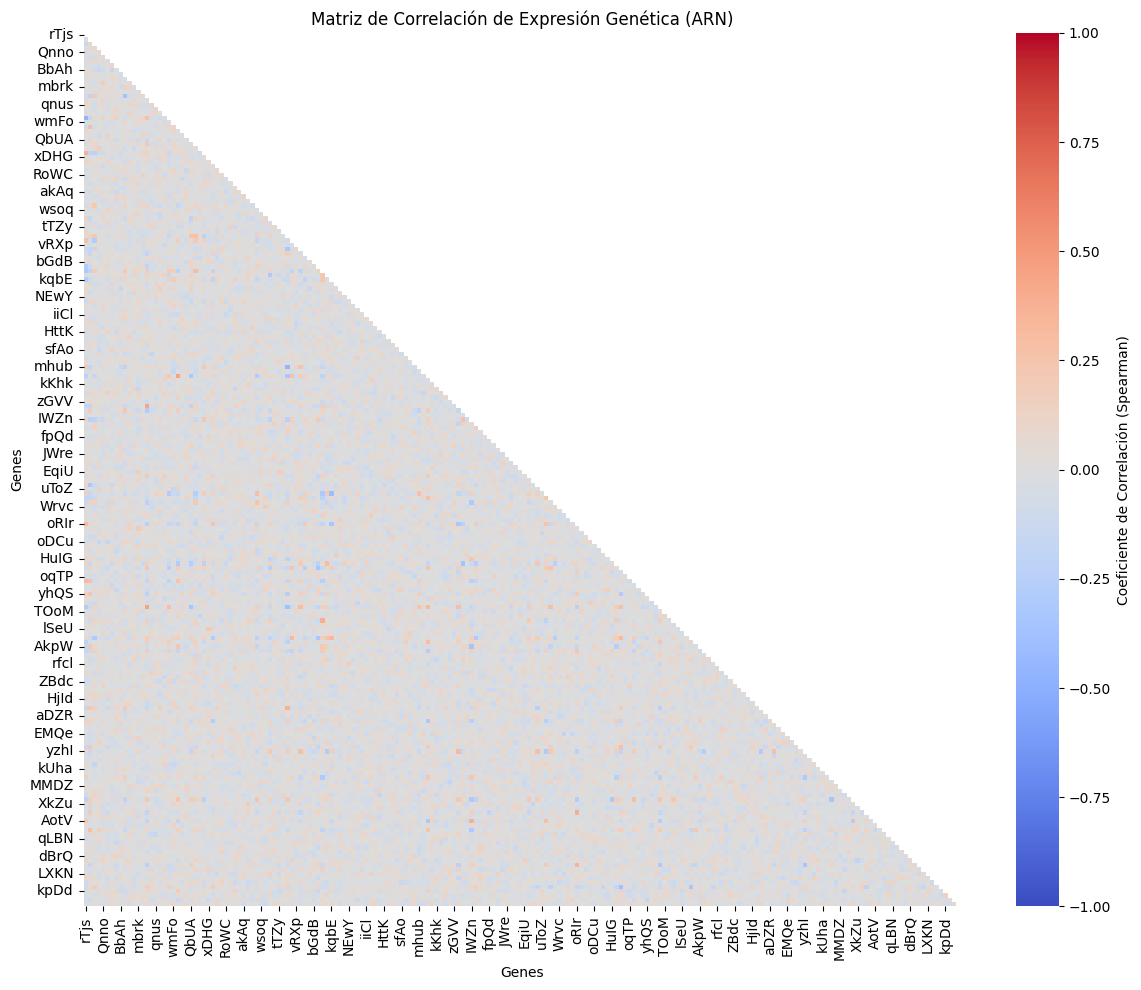

Series([], dtype: float64)


In [ ]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes) # Qué gen tiene una correlación marcada.

#### Correlación dada la Clase

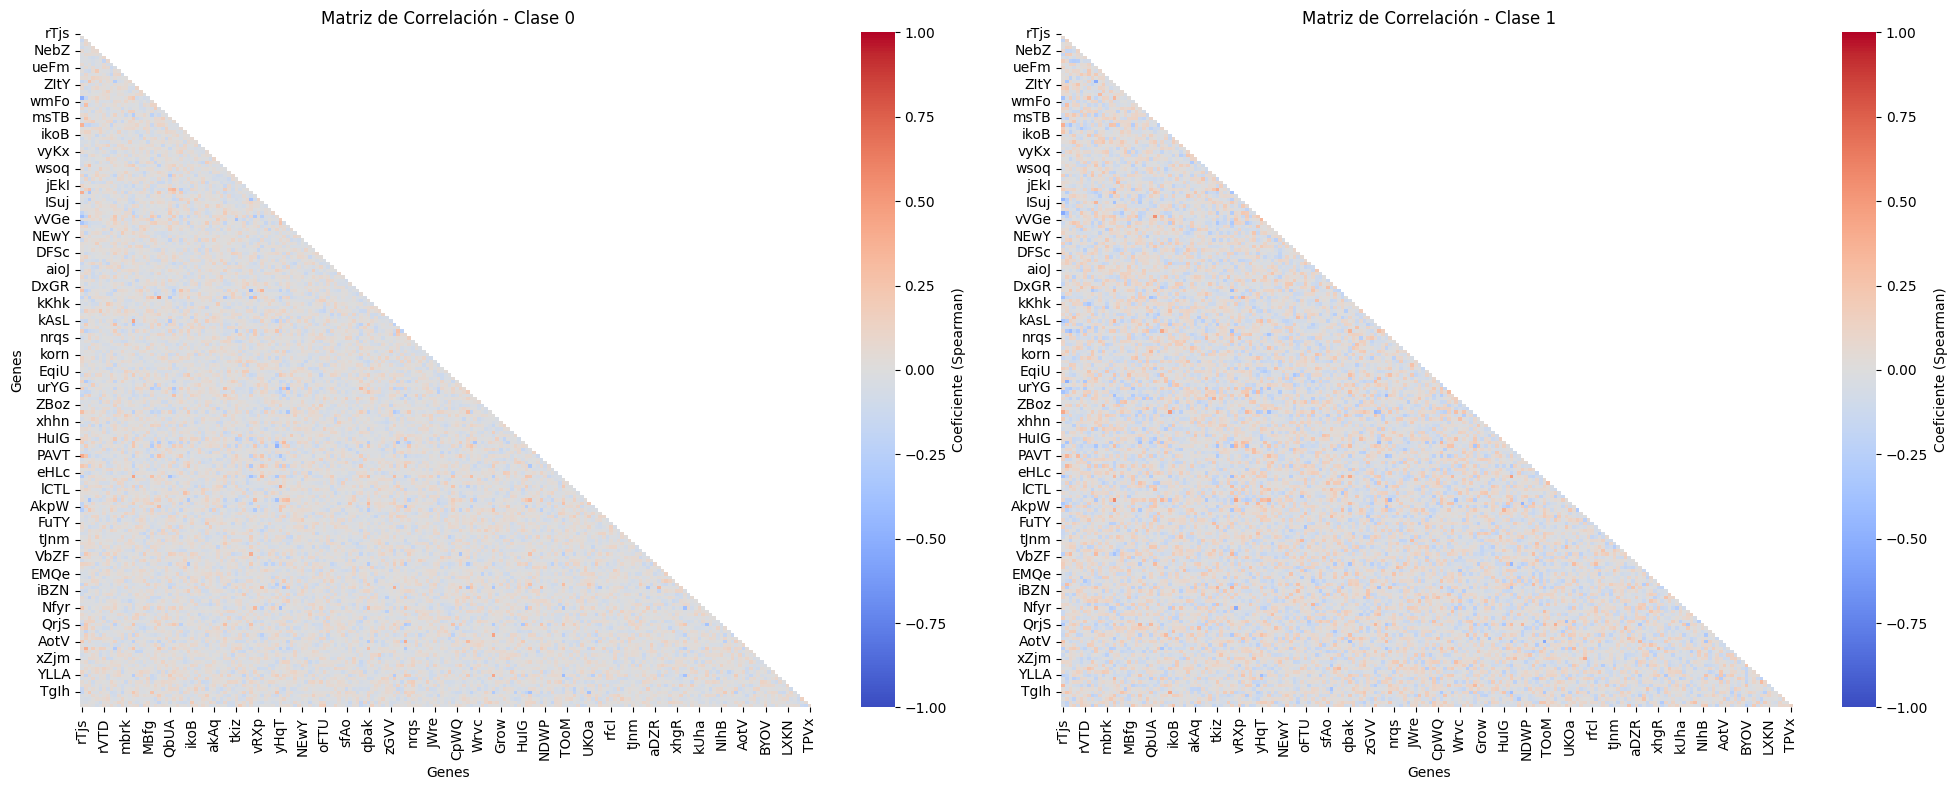

Genes con correlación fuerte en Clase 0:
Series([], dtype: float64)

Genes con correlación fuerte en Clase 1:
Series([], dtype: float64)


In [ ]:
X_0 = df[df['target'] == 0].drop(columns=['target'])
X_1 = df[df['target'] == 1].drop(columns=['target'])

corr_0 = X_0.corr(method='spearman')
corr_1 = X_1.corr(method='spearman')

mask = np.triu(np.ones_like(corr_0, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_0,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[0].set_title('Matriz de Correlación - Clase 0')
axes[0].set_xlabel('Genes')
axes[0].set_ylabel('Genes')

sns.heatmap(
    corr_1,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[1].set_title('Matriz de Correlación - Clase 1')
axes[1].set_xlabel('Genes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
print("Genes con correlación fuerte en Clase 0:")
correlaciones_apiladas_0 = corr_0.mask(mask).stack()
correlaciones_fuertes_0 = correlaciones_apiladas_0[abs(correlaciones_apiladas_0) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_0)

print("\nGenes con correlación fuerte en Clase 1:")
correlaciones_apiladas_1 = corr_1.mask(mask).stack()
correlaciones_fuertes_1 = correlaciones_apiladas_1[abs(correlaciones_apiladas_1) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_1)

### Análisis de Normalidad en los Atributos dada la Clase

In [ ]:
resultados_condicionales = []

for clase in ['0', '1']:
    df_clase = df[df['target'] == clase].drop(columns=['target'])

    for gen in df_clase.columns:
        data = df_clase[gen].dropna()

        _, p_shapiro = shapiro(data)
        es_normal_shapiro = p_shapiro > 0.05

        resultados_condicionales.append({
            'Clase': clase,
            'Gen': gen,
            'p_valor_Shapiro': p_shapiro,
            'Normal_Shapiro': es_normal_shapiro,
        })

df_tests_condicional = pd.DataFrame(resultados_condicionales)

display(df_tests_condicional.sort_values(by=['Clase', 'p_valor_Shapiro'], ascending=[True, True]).head(15))

/tmp/ipykernel_57495/635126186.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_shapiro = shapiro(data)
/tmp/ipykernel_57495/635126186.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_shapiro = shapiro(data)


,Clase,Gen,p_valor_Shapiro,Normal_Shapiro
0,0,rTjs,NaN,False
1,0,Sgqo,NaN,False
2,0,egGJ,NaN,False
3,0,DwEY,NaN,False
4,0,Qnno,NaN,False
5,0,NebZ,NaN,False
6,0,rVTD,NaN,False
7,0,eRIp,NaN,False
8,0,BbAh,NaN,False
9,0,OYJu,NaN,False


#### Histogramas de Atributos dada la Clase

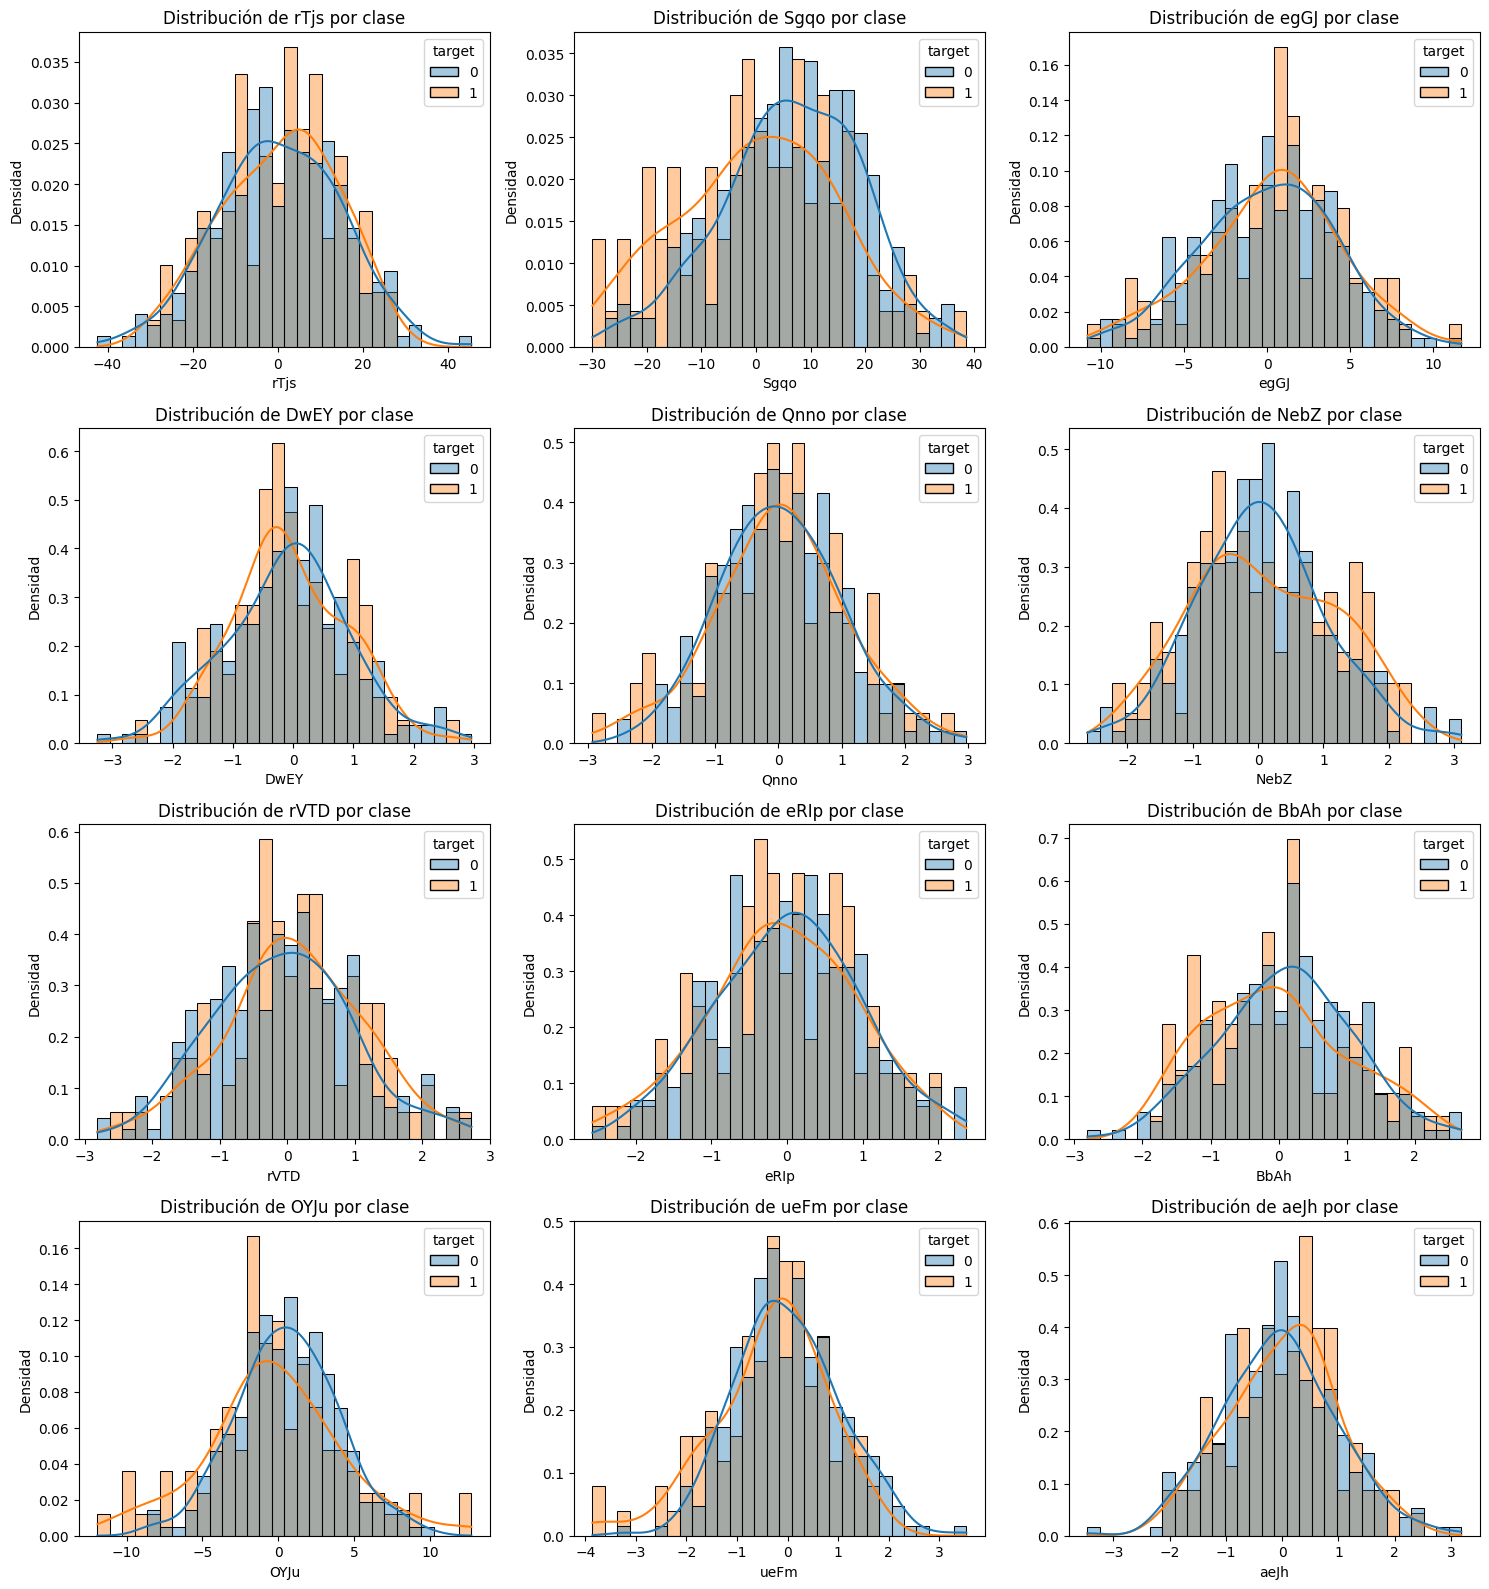

In [ ]:
target = 'target'
features = [col for col in df.columns if col != target]
features = features[:8]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue=target,
        kde=True,
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {feature} por clase")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Densidad")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análisis de Normalidad Multivariable dada la Clase

In [ ]:
def tests_multivariables(df, nombre_dataset="Dataset", target_col='target'):

    print(f"RESULTADOS PARA: {nombre_dataset}")
    print("-" * 50)

    X_clase_0 = df[df[target_col] == 0].drop(columns=[target_col])
    X_clase_1 = df[df[target_col] == 1].drop(columns=[target_col])

    mvn_0 = pg.multivariate_normality(X_clase_0)
    mvn_1 = pg.multivariate_normality(X_clase_1)

    print("Test de Normalidad Multivariable (Henze-Zirkler):")
    print(f"Clase 0 -> Normal: {mvn_0.normal} | p-valor: {mvn_0.pval}")
    print(f"Clase 1 -> Normal: {mvn_1.normal} | p-valor: {mvn_1.pval}\n")

    lista_genes = df.drop(columns=[target_col]).columns.tolist()

    try:
        res_box = pg.box_m(df, dvs=lista_genes, group=target_col)
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"Matrices iguales: {res_box['equal_cov'].iloc[0]} | p-valor: {res_box['pval'].iloc[0]}")
        display(res_box)
    except Exception as e:
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"ERROR MATEMÁTICO: {e}")

    print("=" * 60, "\n")

In [ ]:
tests_multivariables(df, nombre_dataset="Dataset de Desarrollo", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 0.0
Clase 1 -> Normal: False | p-valor: 0.0

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 0.0


/opt/miniconda3/lib/python3.13/site-packages/pingouin/multivariate.py:386: RuntimeWarning: divide by zero encountered in log
  u = -2 * (1 - c) * np.log(M)


,Chi2,df,pval,equal_cov
box,inf,20100.0,0.0,False


No tiene sentido realizar este test al tener solo 400 datos para 200 atributos. Para calcular la matriz de covarianza de 200 variables se necesitarían estimar unas 20 mil relaciones cruzadas, por lo cual no hay suficientes datos para calcularla de manera estable.   

Sin embargo, si discriminamos por aquellos atributos que tienen la mayor varianza entre las medias de sus distribuciones dada la clase, entonces el test puede brindarnos información sobre qué esta pasando. Resulta ser que de esta manera una de las distribuciones dada la clase si es una Normal Multivariable.  

In [ ]:
medias = df.groupby('target').mean()
separacion = medias.var()
atributos_top = separacion.nlargest(40).index.tolist()

df_medias = df[atributos_top + ['target']].copy()

tests_multivariables(df_medias, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 0.0007641054815960026
Clase 1 -> Normal: True | p-valor: 0.2910473383112425

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 0.0


/opt/miniconda3/lib/python3.13/site-packages/pingouin/multivariate.py:386: RuntimeWarning: divide by zero encountered in log
  u = -2 * (1 - c) * np.log(M)


,Chi2,df,pval,equal_cov
box,inf,820.0,0.0,False


El método inicial solo evaluaba la distancia entre las medias. Para mejorar la selección, es necesario ponderar la importancia de cada atributo penalizando por su varianza. Este enfoque es, en esencia, el Análisis de Varianza (ANOVA).

In [ ]:
X = df.drop(columns=['target'])
y = df['target']
k_mejores = 40

selector = SelectKBest(score_func=f_classif, k=k_mejores)
selector.fit(X, y)

atributos_top = X.columns[selector.get_support()].tolist()

df_anova = df[atributos_top + ['target']].copy()

tests_multivariables(df_anova, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos - ANOVA)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos - ANOVA)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: True | p-valor: 0.470428834743723
Clase 1 -> Normal: True | p-valor: 0.33792164600309016

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 2.5833228773458537e-20


,Chi2,df,pval,equal_cov
box,1248.054985,820.0,2.583323e-20,False



### Modelos en Filtrando Atributos

Siguiendo la idea anterior, probamos nuevos modelos.

In [ ]:
# filtrando por medias
medias = df.groupby('target').mean()
separacion = medias.var()
y = df['target']

res_roc = []
res_accuracy = []

for k in range(1, 50):

    atributos_top = separacion.nlargest(40).index.tolist()
    X = df[atributos_top]

    #nb_model = LinearDiscriminantAnalysis()
    nb_model = QuadraticDiscriminantAnalysis(reg_param=0.01)
    #nb_model = GaussianNB()
    nb_model = SVC(params={'kernel': 'rbf', 'C': -3})

    resultados_nb = cross_validate(
        nb_model,
        X,
        y,
        cv=stratifiedKFold,
        scoring='roc_auc'
    )

    res_roc.append((k, aucroc_promedio_nb))
    aucroc_promedio_nb = resultados_nb['test_score'].mean()
    res_accuracy.append((k, resultados_nb['test_score'].mean()))
    #print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

res_roc.sort(key=lambda x: x[1], reverse=True)
res_accuracy.sort(key=lambda x: x[1], reverse=True)

In [ ]:
df_scores = pd.DataFrame({
    'Num_Atributos': [x[0] for x in res_roc],
    'AUCROC': [x[1] for x in res_roc],
    'Accuracy': [x[1] for x in res_accuracy]
})

df_scores

,Num_Atributos,AUCROC,Accuracy
0,1,0.971246,0.971246
1,2,0.971246,0.971246
2,3,0.971246,0.971246
3,4,0.971246,0.971246
4,5,0.971246,0.971246
5,6,0.971246,0.971246
6,7,0.971246,0.971246
7,8,0.971246,0.971246
8,9,0.971246,0.971246
9,10,0.971246,0.971246


In [ ]:
# filtrando por ANOVA
res_roc = []
res_accuracy = []
y = df['target']

for k in range(1, 50):
    X = df.drop(columns=['target'])


    selector = SelectKBest(score_func=f_classif, k=k, random_state=SEED)
    selector.fit(X, y)

    atributos_top = X.columns[selector.get_support()].tolist()

    X = df[atributos_top]

    #nb_model = LinearDiscriminantAnalysis()
    nb_model = QuadraticDiscriminantAnalysis(reg_param=0.01)
    #nb_model = GaussianNB()
    nb_model = SVC(params={'kernel': 'rbf', 'C': -3})

    resultados_nb = cross_validate(
        nb_model,
        X,
        y,
        cv=stratifiedKFold,
        scoring='roc_auc'
    )

    res_roc.append((k, aucroc_promedio_nb))
    aucroc_promedio_nb = resultados_nb['test_score'].mean()
    res_accuracy.append((k, resultados_nb['test_score'].mean()))
    #print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

res_roc.sort(key=lambda x: x[1], reverse=True)
res_accuracy.sort(key=lambda x: x[1], reverse=True)

TypeError: SelectKBest.__init__() got an unexpected keyword argument 'random_state'

In [ ]:
# transformar res_roc y res_accuracy en un mismo dataframe
df_scores = pd.DataFrame({
    'Num_Atributos': [x[0] for x in res_roc],
    'AUCROC': [x[1] for x in res_roc],
    'Accuracy': [x[1] for x in res_accuracy]
})

df_scores

,Num_Atributos,AUCROC,Accuracy
0,42,0.867549,0.867549
1,47,0.863266,0.863266
2,41,0.861008,0.861008
3,48,0.860965,0.860965
4,43,0.853424,0.853424
5,1,0.848058,0.848058
6,31,0.847754,0.847754
7,45,0.847307,0.847307
8,32,0.846034,0.846034
9,46,0.843343,0.843343
